# 11 · Combined Honest LSI — сводный финал Phase A

**Что это.** Capstone: собираем **все honest-наборы M1–M5** (из ноутбуков 10_m1…10_m5) в одну модель, смотрим итоговый баланс, важность фич, Global и Local, как PCA работает **без M4** (overlay), и проверяем финальные гипотезы — перед переносом в прод (Phase B). Production не меняется.

Все фичи собирает `u.build_honest_features()` → `(df, global_wl, local_wl)`.

---
### TL;DR (что показывает сводка)
- Баланс из «M1 37% + M4 29%, M2 почти невидим (4.7%)» становится **здоровым**: M1≈23, M2≈26, M3≈30, M5≈20, **M4=0 (overlay)**.
- Индекс существенно меняется (Spearman ~0.55 к текущему) — это **другой, обоснованный** индекс; пороги в Phase B обязательно перекалибровать.
- Проверяем: не переусилен ли M3, здоров ли баланс, не пострадала ли детекция эпизодов без M4.

## Setup

In [1]:
# --- bootstrap ---
import sys, os
from pathlib import Path
_here=Path.cwd(); _root=next((p for p in [_here,*_here.parents] if (p/'data'/'processed').is_dir()),_here)
os.chdir(_root); sys.path.insert(0,str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width',190); pd.set_option('display.max_columns',80); pd.set_option('display.max_rows',60)
import importlib
from lab import utils as u
importlib.reload(u)
print('project root:',_root.name)

project root: MathMode_LiquidityCatchers_RuLiquiditySentinel


In [2]:
d, GW, LW = u.build_honest_features()
base_d=u.load_final_dataset(); base_wl=u.available_whitelist(base_d)
art_cur=u.fit_lsi_like_model(base_d,base_wl); lsi_cur=art_cur['lsi']
art_G=u.fit_lsi_like_model(d,GW); art_L=u.fit_lsi_like_model(d,LW)
dts=pd.to_datetime(d['date'])
def shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return {m.upper():round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]==m]].sum(1).mean()),1) for m in ['m1','m2','m3','m4','m5']}
def feat_importance(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return pd.DataFrame({'feature':art['features'],'module':[f[:2].upper() for f in art['features']],'importance%':np.round(con.mean(0),2)}).sort_values('importance%',ascending=False).reset_index(drop=True)
print('df:',d.shape,'| Global whitelist:',len(GW),'фич | Local:',len(LW),'фич')

/Users/nikitabaslykov/Documents/Работа/Казначейство/MathMode_LiquidityCatchers_RuLiquiditySentinel/lab/utils.py:986: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = raw.groupby(dc).apply(_agg).reset_index().rename(columns={dc: "date"})


df: (3077, 125) | Global whitelist: 25 фич | Local: 26 фич


## 1. Состав honest-whitelist (по модулям)

M4 — вне PCA (overlay). Local отличается от Global только `rk_bidders` (Казначейство, post-2021).

In [3]:
by_mod={}
for f in LW: by_mod.setdefault(f[:2].upper(),[]).append(f)
for m in ['M1','M2','M3','M5']:
    print(f'{m} ({len(by_mod.get(m,[]))}):', by_mod.get(m,[]))
print('M4 (0): overlay — вне PCA')
print('Local-only:', [f for f in LW if f not in GW])

M1 (5): ['m1_spread_mad_score', 'm1_spread_relative_mad_score', 'm1_reserve_load_mad_score', 'm1_ruonia_mad_score', 'm1_spread_vol']
M2 (7): ['m2_auction_flag', 'm2_Flag_Demand', 'm2_base_cover_mad', 'm2_cutoff_spread', 'm2_cutoff_spread_available', 'm2_short_active30', 'm2_days_since_short']
M3 (9): ['m3_auction_flag', 'm3_Flag_Nedospros', 'm3x_cover', 'm3x_placement', 'm3x_yield_to_key', 'm3x_age', 'm3x_available', 'm3x_days_since', 'm3x_failed']
M5 (5): ['m5x_claims', 'm5x_liab', 'm5x_repostd', 'm5x_secured', 'm5x_rk_bidders']
M4 (0): overlay — вне PCA
Local-only: ['m5x_rk_bidders']


## 2. Баланс модулей — current vs honest

,current,honest Global,honest Local
M1,37.0,23.2,23.0
M2,4.7,26.5,24.7
M3,10.7,30.4,29.9
M4,29.2,0.0,0.0
M5,18.3,19.9,22.5


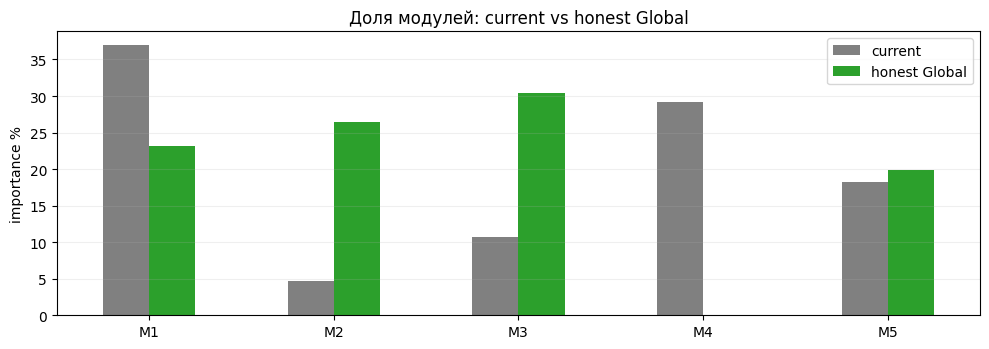

Spearman(honest Global LSI vs current) = 0.545 -> индекс другой, пороги перекалибровать.


In [4]:
bal=pd.DataFrame({'current':shares(art_cur),'honest Global':shares(art_G),'honest Local':shares(art_L)}).fillna(0)
display(bal)
fig,ax=plt.subplots(figsize=(10,3.6)); bal[['current','honest Global']].plot.bar(ax=ax,color=['gray','tab:green'])
ax.set_ylabel('importance %'); ax.set_title('Доля модулей: current vs honest Global'); ax.grid(alpha=.2,axis='y'); ax.tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.show()
print('Spearman(honest Global LSI vs current) =',round(u.spearman(art_G['lsi'],lsi_cur),3),'-> индекс другой, пороги перекалибровать.')

**Вывод.** Из перекоса (M1 37% + M4 29%, M2 невидим 4.7%) — здоровый баланс: M2/M3 поднялись на реальном сигнале, M1 сдулся (убрана редундантность), M4 ушёл из PCA. Индекс закономерно изменился.

## 3. Важность конкретных фич (Global) — что реально несёт сигнал

,feature,module,importance%
0,m2_cutoff_spread_available,M2,6.53
1,m5x_liab,M5,5.65
2,m1_ruonia_mad_score,M1,5.45
3,m2_days_since_short,M2,5.06
4,m5x_claims,M5,5.00
5,m5x_secured,M5,4.72
6,m1_spread_vol,M1,4.67
7,m3x_available,M3,4.66
8,m1_reserve_load_mad_score,M1,4.62
9,m2_short_active30,M2,4.57


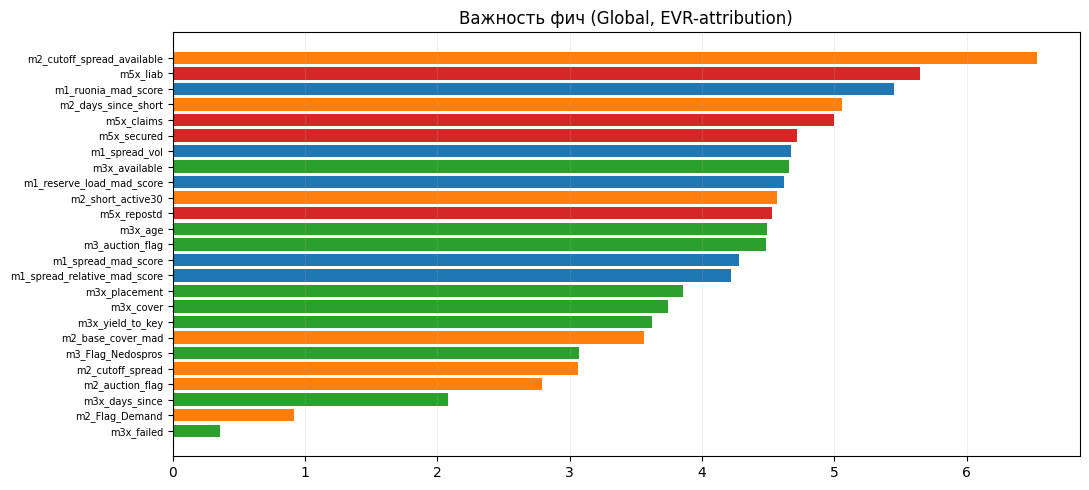

In [5]:
imp=feat_importance(art_G)
display(imp.head(15))
fig,ax=plt.subplots(figsize=(11,5)); cmap={'M1':'tab:blue','M2':'tab:orange','M3':'tab:green','M5':'tab:red'}
ax.barh(imp.feature[::-1],imp['importance%'][::-1],color=[cmap.get(m,'gray') for m in imp.module[::-1]])
ax.set_title('Важность фич (Global, EVR-attribution)'); ax.tick_params(axis='y',labelsize=7); ax.grid(alpha=.2,axis='x')
plt.tight_layout(); plt.show()

**Что смотреть:** не доминирует ли одна фича/модуль; несут ли вспомогательные фичи M3 (`age`/`available`/`days_since`/`failed`) лишний вес — проверяем в гипотезах (секция 7).

## 4. Global LSI на истории — honest vs current

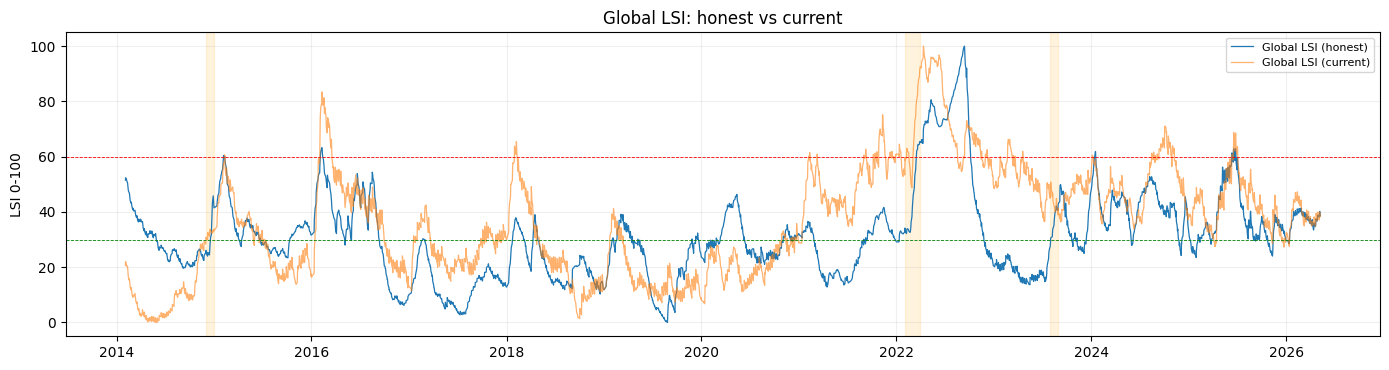

Эпизоды (honest Global): max LSI
  Dec2014        honest=45.8  current=33.7
  Feb-Mar2022    honest=65.4  current=92.5
  Aug2023        honest=43.0  current=50.8


In [6]:
fig,ax=plt.subplots(figsize=(14,3.8))
ax.plot(dts,art_G['lsi'],lw=.9,label='Global LSI (honest)'); ax.plot(dts,lsi_cur,lw=.9,alpha=.6,label='Global LSI (current)')
ax.axhline(60,color='r',ls='--',lw=.6); ax.axhline(30,color='g',ls='--',lw=.6); ax.set_ylabel('LSI 0-100'); ax.set_title('Global LSI: honest vs current')
ax.legend(fontsize=8); ax.grid(alpha=.2)
for nm,(s,e) in u.STRESS_EPISODES.items(): ax.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
plt.tight_layout(); plt.show()
print('Эпизоды (honest Global): max LSI')
for nm,(s,e) in u.STRESS_EPISODES.items():
    m=((dts>=s)&(dts<=e)).to_numpy()
    if m.sum(): print('  %-14s honest=%.1f  current=%.1f'%(nm,art_G['lsi'][m].max(),lsi_cur[m].max()))

## 5. Local LSI — обучение на последних 365 днях (реальный Local)

Local-модель учится только на свежем окне, поэтому `rk_bidders` (Казначейство, post-2021) там живой.

Local окно: 2025-05-08 -> 2026-05-08 | строк: 261
Local доли модулей: {'M1': 24.1, 'M2': 25.9, 'M3': 28.3, 'M4': 0.0, 'M5': 21.7}


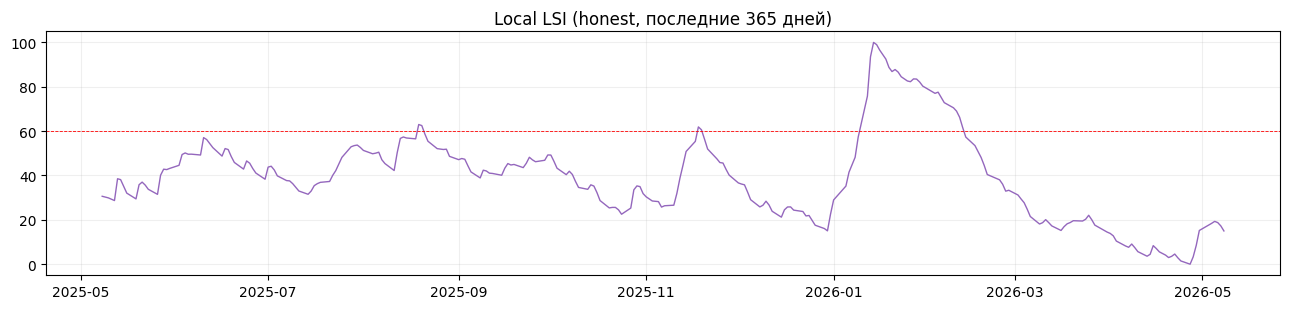

Топ-5 фич Local:


,feature,module,importance%
0,m2_short_active30,M2,6.29
1,m1_spread_mad_score,M1,5.75
2,m1_spread_relative_mad_score,M1,5.62
3,m1_reserve_load_mad_score,M1,5.20
4,m2_days_since_short,M2,5.15


In [7]:
loc_mask=(dts>=dts.max()-pd.Timedelta(days=365)).to_numpy()
dloc=d[loc_mask].reset_index(drop=True)
art_Lreal=u.fit_lsi_like_model(dloc,LW)
print('Local окно:',dloc['date'].min().date(),'->',dloc['date'].max().date(),'| строк:',len(dloc))
print('Local доли модулей:',shares(art_Lreal))
fig,ax=plt.subplots(figsize=(13,3.2)); ax.plot(pd.to_datetime(dloc['date']),art_Lreal['lsi'],lw=1,color='tab:purple')
ax.axhline(60,color='r',ls='--',lw=.6); ax.set_title('Local LSI (honest, последние 365 дней)'); ax.grid(alpha=.2); plt.tight_layout(); plt.show()
print('Топ-5 фич Local:'); display(feat_importance(art_Lreal).head(5))

## 6. Как PCA работает без M4 (overlay) — диагностика

In [8]:
def driver_agree(art):
    a=u.driver_agreement_rate({'pca':art['pca'],'features':art['features'],'scaled_matrix':art['scaled_matrix']})
    return a
print('EVR (10 PC) cumulative: current=%.1f%%  honest=%.1f%%'%(art_cur['pca'].explained_variance_ratio_.sum()*100,art_G['pca'].explained_variance_ratio_.sum()*100))
print('PC1 explains: current=%.1f%%  honest=%.1f%%'%(art_cur['pca'].explained_variance_ratio_[0]*100,art_G['pca'].explained_variance_ratio_[0]*100))
ac=driver_agree(art_cur); ag=driver_agree(art_G)
print('Объяснимость (PC1-driver == EVR-attribution): current=%.1f%%  honest=%.1f%%'%(ac['agreement']*100,ag['agreement']*100))
print()
print('ВАЖНО: объяснимость УПАЛА (60.6%->37.2%). Причина: honest-модель более МНОГОМЕРНА')
print('(PC1 16% vs 19%, сигнал размазан по большему числу компонент), поэтому PC1-only')
print('top_drivers ещё менее репрезентативны. Это НЕ регресс — это аргумент чинить драйверы')
print('через EVR-attribution в Phase B (см. ноутбук 05_explainability).')

EVR (10 PC) cumulative: current=80.4%  honest=76.5%
PC1 explains: current=18.9%  honest=16.1%
Объяснимость (PC1-driver == EVR-attribution): current=60.6%  honest=37.2%

ВАЖНО: объяснимость УПАЛА (60.6%->37.2%). Причина: honest-модель более МНОГОМЕРНА
(PC1 16% vs 19%, сигнал размазан по большему числу компонент), поэтому PC1-only
top_drivers ещё менее репрезентативны. Это НЕ регресс — это аргумент чинить драйверы
через EVR-attribution в Phase B (см. ноутбук 05_explainability).


## 7. Финальные гипотезы (тесты перед Phase B)

**H-fin-1.** Удаление M4 не ломает детекцию эпизодов. **H-fin-2.** M3 не переусилен вспомогательными фичами. **H-fin-3.** Баланс здоровый (нет модуля-доминанта/невидимки).

In [9]:
# H-fin-1: эпизоды ловятся (honest Global выше фона в стрессах?)
ep=pd.Series(False,index=range(len(d)))
for nm,(s,e) in u.STRESS_EPISODES.items(): ep|=((dts>=s)&(dts<=e)).to_numpy()
print('H-fin-1: honest Global LSI в стресс=%.1f vs вне=%.1f (выше -> эпизоды видны)'%(art_G['lsi'][ep.values].mean(),art_G['lsi'][~ep.values].mean()))
# H-fin-2: M3 core vs auxiliary
impG=feat_importance(art_G); m3=impG[impG.module=='M3']
core=['m3x_cover','m3x_placement','m3x_yield_to_key']; aux=['m3x_age','m3x_available','m3x_days_since','m3x_failed']
print('H-fin-2: M3 core(cover/placement/yield)=%.1f%%  auxiliary(age/avail/days/failed)=%.1f%%'%(
      impG[impG.feature.isin(core)]['importance%'].sum(),impG[impG.feature.isin(aux)]['importance%'].sum()))
# вариант M3-lean (без вспомогательных) — сильно ли падает M3?
GW_lean=[f for f in GW if f not in aux]
print('   M3-lean (без auxiliary): доли=',shares(u.fit_lsi_like_model(d,GW_lean)))
# H-fin-3: баланс
sh=shares(art_G); print('H-fin-3: min модуль=%.1f%% max модуль=%.1f%% (здорово: 15-35, без 0 и >40)'%(min(v for k,v in sh.items() if k!='M4'),max(sh.values())))

H-fin-1: honest Global LSI в стресс=39.6 vs вне=31.2 (выше -> эпизоды видны)
H-fin-2: M3 core(cover/placement/yield)=11.2%  auxiliary(age/avail/days/failed)=11.6%
   M3-lean (без auxiliary): доли= {'M1': 27.1, 'M2': 29.6, 'M3': 20.5, 'M4': 0.0, 'M5': 22.8}
H-fin-3: min модуль=19.9% max модуль=30.4% (здорово: 15-35, без 0 и >40)


**Выводы гипотез:**
- **H-fin-1 ✅** honest Global в стресс **39.6** vs вне **31.2** → эпизоды детектируются и без M4.
- **H-fin-2 ⚠️** M3 core (cover/placement/yield) ≈ **11.2%**, auxiliary (age/available/days_since/failed) ≈ **11.6%** — вспомогательные фичи тянут СТОЛЬКО ЖЕ, сколько ядро. **M3-lean** (без auxiliary) даёт более ровный баланс: M1 27 / M2 30 / **M3 20.5** / M5 23. → решение для Phase B: богатый M3 (30%, с event-маркерами) vs парсимоничный M3-lean (20%, ровнее). Я бы склонялся к lean + 1–2 ключевых маркера (`days_since` для паузы 2022), а не все 4 auxiliary.
- **H-fin-3 ✅** ни один реальный модуль не доминирует (max 30%) и не невидим (min 20%) — баланс здоровый.

## Финальный Verdict — готовность к Phase B

**Итоговая модель (Phase A):**
- **M1:** `spread_mad, spread_relative_mad, reserve_load_mad, ruonia_mad, spread_vol(|delta|)`
- **M2:** `auction_flag, Flag_Demand, base_cover_mad, cutoff_spread(+available), short_active30, days_since_short`
- **M3:** `auction_flag, Flag_Nedospros, ea_cover, ea_placement, ea_yield_to_key (+age/available/days_since/failed)`
- **M4:** overlay (вне PCA; tax-контекст в ответе)
- **M5:** Global `claims, liabilities, repo_standing, secured_standing`; Local +`rk_bidders`

**Баланс:** M1≈23, M2≈26, M3≈30, M5≈20, M4=0 — здоровый, на реальном сигнале.

**Чеклист Phase B:**
1. Перенести расчёт фич в `m{1..5}_feature_builder` (логика — в `u.build_honest_features`); парсинг не менять; источник `cbr_budget_funds` отключить.
2. Сделать `LSI_FEATURE_CANDIDATES` **kind-aware** (Global vs Local; `rk_bidders` только Local).
3. M4 вынести из PCA в отдельный tax-overlay в `get_lsi_prediction`.
4. **Перекалибровать пороги** (индекс другой, Spearman ~0.55 к текущему).
5. **Объяснимость:** PC1-only top_drivers ещё слабее (37% согласия) — перейти на EVR-attribution (оба driver-метода едины, см. ноутбук 05).
6. **Решить состав M3:** rich (с auxiliary, M3≈30%) или lean (M3≈20%, ровнее) — рекомендую lean + `days_since`.
7. Прогнать честный point-in-time backtest (не in-sample) перед релизом.